# Global pressure-based models: Main article figures

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import geopandas as gpd
from scipy.stats import pearsonr
from scipy.special import logit
import gower
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm, Normalize, LinearSegmentedColormap
from pathlib import Path
import jupyter_black
import textwrap
import warnings
import statsmodels.api as sm
import tempfile
import subprocess
import json

jupyter_black.load()

## Visual settings across all plots

In [4]:
# Set global Seaborn theme
sns.set_theme(
    style="white",  # White background
    context="notebook",  # Default context; adjust font sizes for notebooks
    rc={
        "axes.spines.top": False,  # Remove top spine
        "axes.spines.right": False,  # Remove right spine
        "axes.grid": False,  # Disable gridlines
        "xtick.bottom": True,  # Enable bottom ticks
        "ytick.left": True,  # Enable left ticks
        "xtick.major.size": 6,  # Length of major x-axis ticks
        "ytick.major.size": 6,  # Length of major y-axis ticks
        "axes.titlesize": 14,  # Font size for titles
        "axes.labelsize": 11,  # Font size for axis labels
        "legend.fontsize": 11,  # Font size for legends
    },
)

color_scheme = {  # https://matplotlib.org/stable/gallery/color/named_colors.html
    "calibration": "teal",
    "fixed_eff": "lightsteelblue",
    "random_eff": "peachpuff",
    "training": "darkgray",
    "standard_cv": "darkseagreen",
    "cross_study_cv": "mediumseagreen",
    "train_line": "royalblue",
    "test_line": "orange",
    "group_scatter": "darkolivegreen",
}

summary_colors = {
    "Training": color_scheme["training"],
    "Standard CV": color_scheme["standard_cv"],
    "Cross-study CV": color_scheme["cross_study_cv"],
}

## Source folder paths for base model runs

In [ ]:
# ALPHA diversity: Base model runs

lmm_alpha_folders = {
    "Training": "lmm_alpha_train",
    "Standard CV": "lmm_alpha_standard_cv",
    "Cross-study CV": "lmm_alpha_cross_study",
}

bhm_alpha_folders = {
    "Training": "bhm_alpha_train_sqrt",
    "Standard CV": "bhm_alpha_standard_cv_sqrt",
    "Cross-study CV": "bhm_alpha_cross_study_sqrt",
}

# BETA diversity: Base model runs

lmm_beta_folders = {
    "Training": "lmm_beta_train",
    "Standard CV": "lmm_beta_standard_cv",
    "Cross-study CV": "lmm_beta_cross_study",
}

bhm_beta_folders = {
    "Training": "bhm_beta_train_log",
    "Standard CV": "bhm_beta_standard_cv_log",
    "Cross-study CV": "bhm_beta_cross_study_log",
}

# Base paths and file endings
base_path = "../../data/saved_runs"
key_output_path = "key_output"
site_info_filename = "site_info.parquet"
bhm_added_output_path = "additional_output"

# Figure 2: Model performance summary

## Extract data from training and cross-validation runs

In [6]:
def load_prediction_dataframes(
    mode_folders: dict[str, str],
    base_path: str = base_path,
) -> dict[str, pl.DataFrame]:
    """
    Load prediction dataframes from run folders. Given {mode: run_folder},
    return {mode: df_predictions}.

    Training runs read key_output/train_predictions.parquet.
    Cross-validation runs read key_output/test_predictions_fold_*.parquet and
    concatenate the test folds (with fold and mode labels).
    """
    out = {}
    for mode, run_folder in mode_folders.items():
        run_path = Path(base_path) / run_folder
        key_output_dir = run_path / "key_output"

        if "training" in mode.lower():
            df = pl.read_parquet(run_path / "key_output" / "train_predictions.parquet")
            df = df.with_columns(pl.lit("Training").alias("mode"))
        else:
            test_files = sorted(
                key_output_dir.glob("test_predictions_fold_*.parquet"),
                key=lambda p: int(p.stem.split("_")[-1]),
            )
            dfs = []
            for i, test_path in enumerate(test_files, start=1):
                df_fold = pl.read_parquet(test_path)
                df_fold = df_fold.with_columns(
                    [
                        pl.lit(i).alias("fold"),
                        pl.lit("test").alias("mode"),
                    ]
                )
                dfs.append(df_fold)
            df = pl.concat(dfs, how="vertical", rechunk=True)

        out[mode] = df

    return out

In [50]:
# Produce dicts of model and mode dataframes from data path dict
lmm_alpha_results = load_prediction_dataframes(lmm_alpha_folders)
bhm_alpha_results = load_prediction_dataframes(bhm_alpha_folders)
lmm_beta_results = load_prediction_dataframes(lmm_beta_folders)
bhm_beta_results = load_prediction_dataframes(bhm_beta_folders)

## Check number of observations in each model

In [8]:
print("LMM alpha shapes:")
for mode in lmm_alpha_results.keys():
    df = lmm_alpha_results[mode]
    print(f"{mode}, {df.shape}")

LMM alpha shapes:
Training, (25987, 6)
Standard CV, (25987, 7)
Cross-study CV, (25987, 7)


In [38]:
print("BHM alpha shapes:")
for mode in bhm_alpha_results.keys():
    df = bhm_alpha_results[mode]
    print(f"{mode}, {df.shape}")

BHM alpha shapes:
Training, (31242, 7)
Standard CV, (31242, 8)
Cross-study CV, (31242, 8)


In [10]:
print("LMM beta shapes:")
for mode in lmm_beta_results.keys():
    df = lmm_beta_results[mode]
    print(f"{mode}, {df.shape}")

LMM beta shapes:
Training, (29088, 6)
Standard CV, (29088, 7)
Cross-study CV, (29088, 7)


In [39]:
print("BHM beta shapes:")
for mode in bhm_beta_results.keys():
    df = bhm_beta_results[mode]
    print(f"{mode}, {df.shape}")

BHM beta shapes:
Training, (32937, 7)
Standard CV, (32937, 8)
Cross-study CV, (32937, 8)


## Calculate summary stats per model and mode

In [12]:
def _infer_model_family(model_name: str) -> str:
    return "lmm" if "lmm" in model_name.lower() else "bhm"


def _pick_pred_col(mode: str, model_family: str) -> str:
    """Choose which prediction column name to use, since these are different
    between the two model types."""
    model_family = model_family.lower()
    if model_family == "bhm":
        name = "Predicted"
    else:  # For LMMs there are two modes, with / without random effects
        if "training" in mode.lower():
            name = "Predicted_RE"  # Including random effects
        else:
            name = "Predicted_FE"  # Only fixed effects

    return name


def build_model_performance_summary(
    dfs: dict[str, dict[str, pl.DataFrame]],
    true_col: str = "Observed",
) -> pl.DataFrame:
    """
    Build a performance summary table for a set of predictive models. For
    training, only the mean Pearson correlation is computed, while for test
    modes, fold-wise correlations, including min / max, are also calculated.
    """
    rows = []
    for model_name, modes in dfs.items():
        model_family = _infer_model_family(model_name)  # Identify model type

        for mode_name, df in modes.items():
            # Pick correct prediction column for this (model family × mode)
            pred_col = _pick_pred_col(mode_name, model_family)

            # Compute overall Pearson correlation for this mode
            mean_r = float(df.select(pl.corr(true_col, pred_col)).item())

            row = {
                "Model": model_name,
                "Eval type": mode_name,
                "Mean": mean_r,
                "Min": float("nan"),  # Placeholders
                "Max": float("nan"),
            }

            # Cross-validation modes provide fold-wise results
            if ("training" not in mode_name.lower()) and ("fold" in df.columns):
                # Compute r for each fold separately
                per_fold_r = (
                    df.group_by("fold")
                    .agg(pl.corr(true_col, pred_col).alias("r"))
                    .sort("fold")
                )

                # Add each fold’s correlation as its own column
                for fold_val, r_val in zip(
                    per_fold_r["fold"].to_list(), per_fold_r["r"].to_list()
                ):
                    row[f"r_fold_{fold_val}"] = float(r_val)

                # Compute the minimum and maximum performance across folds
                stats = per_fold_r.select(
                    pl.col("r").min().alias("min"),
                    pl.col("r").max().alias("max"),
                ).row(0)
                row["Min"], row["Max"] = map(float, stats)

            rows.append(row)

    return pl.DataFrame(rows)

In [51]:
alpha_summary_results = build_model_performance_summary(
    dfs={
        "LMM alpha": lmm_alpha_results,
        "BHM alpha": bhm_alpha_results,
    }
)
alpha_summary_results

Model,Eval type,Mean,Min,Max,r_fold_1,r_fold_2,r_fold_3,r_fold_4,r_fold_5
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""LMM alpha""","""Training""",0.778623,NaN,NaN,null,null,null,null,null
"""LMM alpha""","""Standard CV""",0.156604,0.146255,0.169745,0.162143,0.151752,0.169745,0.155812,0.146255
"""LMM alpha""","""Cross-study CV""",0.158108,0.030941,0.26195,0.194116,0.26195,0.162328,0.122117,0.030941
"""BHM alpha""","""Training""",0.73712,NaN,NaN,null,null,null,null,null
"""BHM alpha""","""Standard CV""",0.440122,0.436608,0.44368,0.437508,0.44368,0.441769,0.436608,0.441603
"""BHM alpha""","""Cross-study CV""",0.15854,0.023692,0.288124,0.288124,0.063019,0.023692,0.176439,0.228347


In [52]:
beta_summary_results = build_model_performance_summary(
    dfs={
        "LMM beta": lmm_beta_results,
        "BHM beta": bhm_beta_results,
    }
)
beta_summary_results

Model,Eval type,Mean,Min,Max,r_fold_1,r_fold_2,r_fold_3,r_fold_4,r_fold_5
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""LMM beta""","""Training""",0.809979,NaN,NaN,null,null,null,null,null
"""LMM beta""","""Standard CV""",0.204546,0.178458,0.255141,0.255141,0.216421,0.20152,0.178458,0.184131
"""LMM beta""","""Cross-study CV""",0.162035,0.055086,0.265885,0.10406,0.124737,0.265885,0.055086,0.251049
"""BHM beta""","""Training""",0.767716,NaN,NaN,null,null,null,null,null
"""BHM beta""","""Standard CV""",0.425104,0.356591,0.473906,0.356591,0.421139,0.438944,0.473906,0.441723
"""BHM beta""","""Cross-study CV""",0.153963,0.032501,0.399919,0.146897,0.399919,0.032501,0.245696,0.101222


In [20]:
def model_comparison_barplot(
    summary_df: pl.DataFrame,
    figsize: tuple[int, int] = (6, 4),
    mode_color_scheme: dict[str, str] | None = None,
    show_bar_values: bool = True,
    show_axes_labels_values: bool = True,
    show_legend: bool = True,
    bar_number_size: int = 11,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
) -> plt.Figure:

    df = summary_df.to_pandas()

    # Ordered categories
    model_order = df["Model"].unique().tolist()
    mode_order = ["Training", "Standard CV", "Cross-study CV"]

    # Prepare plot dataframe
    df_plot = df.copy()
    df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=model_order)
    df_plot["Eval type"] = pd.Categorical(df_plot["Eval type"], categories=mode_order)

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df_plot,
        x="Model",
        y="Mean",
        hue="Eval type",
        order=model_order,
        hue_order=mode_order,
        palette=mode_color_scheme,
        errorbar=None,
        ax=ax,
        dodge=True,
        legend=show_legend,
    )

    for bar in ax.patches:
        bar.set_linewidth(0.8)
        bar.set_edgecolor("white")

    # Optional value labels
    if show_bar_values:
        offset_mean = 0.06
        offset_range = 0.015

        # One container per Eval type (hue)
        for mode, container in zip(mode_order, ax.containers):
            mode_rows = df_plot[df_plot["Eval type"] == mode]

            for model, bar in zip(model_order, container.patches):
                row = mode_rows[mode_rows["Model"] == model]
                if row.empty:
                    continue

                mean_val = float(row["Mean"].iloc[0])
                min_val = float(row["Min"].iloc[0])
                max_val = float(row["Max"].iloc[0])

                x = bar.get_x() + bar.get_width() / 2

                if np.isfinite(min_val) and np.isfinite(max_val):
                    ax.text(
                        x,
                        mean_val + offset_range,
                        f"({min_val:.2f}–{max_val:.2f})",
                        ha="center",
                        va="bottom",
                        fontsize=bar_number_size,
                    )

                ax.text(
                    x,
                    mean_val + offset_mean,
                    f"{mean_val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=bar_number_size,
                    fontweight="bold",
                )

    # Axis formatting
    ax.set_yticks([0, 1])
    if show_axes_labels_values:
        ax.set_xlabel("")
        ax.set_ylabel("Pearson's r", fontsize=axes_label_size)
        ax.set_yticklabels(["0", "1"], fontsize=axes_number_size)
        ax.tick_params(axis="x", labelsize=axes_label_size)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_yticklabels([])
        ax.tick_params(
            axis="both", which="both", labelbottom=False, labelleft=False, length=4
        )

    if show_legend:
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(0.8, 1),
            frameon=False,
            fontsize=axes_label_size,
            title="",
        )

    fig.tight_layout()
    return fig

## Fig 2a) Alpha diversity

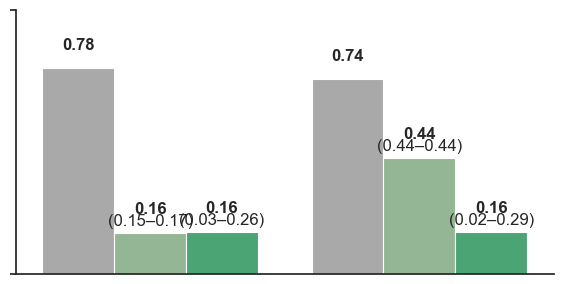

In [59]:
fig = model_comparison_barplot(
    alpha_summary_results,
    figsize=(5.8, 3),
    mode_color_scheme=summary_colors,
    show_bar_values=True,
    show_axes_labels_values=False,
    show_legend=False,
    bar_number_size=12,
    axes_number_size=12,
    axes_label_size=12,
)

In [58]:
fig.savefig("../../documents/plots/alpha_summary.svg", format="svg", transparent=True)

## Fig 2b) Beta diversity

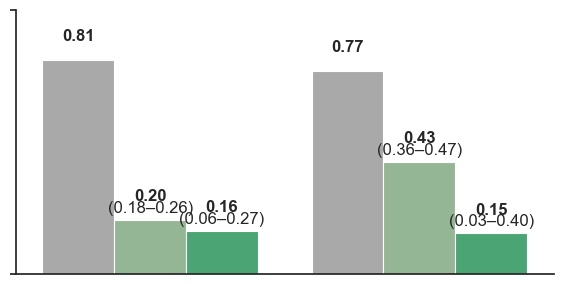

In [63]:
fig = model_comparison_barplot(
    beta_summary_results,
    figsize=(5.8, 3),
    mode_color_scheme=summary_colors,
    show_bar_values=True,
    show_axes_labels_values=False,
    show_legend=False,
    bar_number_size=12,
    axes_number_size=12,
    axes_label_size=12,
)

In [62]:
fig.savefig("../../documents/plots/beta_summary.svg", format="svg", transparent=True)

## Differences in alpha diversity between sites

Only done for alpha diversity predictions, since beta diversity is already a difference metric

In [16]:
def read_site_info_parquet(
    run_folder: str,
    base_path: str = base_path,
    site_info_filename: str = site_info_filename,
) -> pl.DataFrame:
    """
    Helper function for loading the site_info.parquet file for a given run
    folder. Used in several functions in this notebook.
    """
    # Read file
    site_info_file = Path(base_path) / run_folder / site_info_filename
    df_site_info = pl.read_parquet(site_info_file)

    # TEMP until we have outputs from the new runs with fixed source code
    df_site_info = df_site_info.unique(subset=["SSBS"], keep="first")

    return df_site_info

In [17]:
def estimate_delta_predictions(
    state_pred_dfs: dict[str, dict[str, pl.DataFrame]],
    run_folders: dict[str, dict[str, str]],
    grouping_level: str = "SSB",
    reference_comparison_only: bool = False,
) -> dict[str, dict[str, pl.DataFrame]]:
    """
    Compute delta predictions (site_2 - site_1) within a grouping level (SS or
    SSB), for each (model, mode).

    If `Custom_taxonomic_group` exists, deltas are computed within matching
    taxonomic groups. Otherwise, site-level comparisons are used.
    """
    out = {}

    # Get model and modes (training, standard CV, cross-study CV)
    for model, modes in state_pred_dfs.items():
        model_family = _infer_model_family(model)
        out[model] = {}

        # Get the prediction dataframes for each mode
        for mode, df_pred in modes.items():
            pred_col = _pick_pred_col(mode, model_family)  # Family dependent

            # Check if model contains taxonomic groups
            has_taxa = "Custom_taxonomic_group" in df_pred.columns

            # 1. Load site info
            df_site_info = read_site_info_parquet(run_folders[model][mode])

            # 2. Join predictions with metadata
            df_merged = df_pred.join(
                df_site_info.select(
                    ["SSBS", "SSB", "Predominant_land_use", "Use_intensity"]
                ),
                on="SSBS",
                how="left",
            )

            rows = []

            # 3. Partition by grouping unit (SS or SSB)
            for df_group in df_merged.partition_by(grouping_level, as_dict=False):

                # Partition into sites
                site_frames = {}
                site_taxa_frames = {}
                site_is_baseline = {}

                for df_site in df_group.partition_by("SSBS", as_dict=False):
                    site_id = df_site["SSBS"][0]
                    site_frames[site_id] = df_site

                    site_is_baseline[site_id] = (
                        bool(  # Check if current site is baseline
                            (
                                (
                                    df_site["Predominant_land_use"]
                                    == "Primary vegetation"
                                )
                                & (df_site["Use_intensity"] == "Minimal use")
                            ).any()
                        )
                    )

                    if has_taxa:
                        site_taxa_frames[site_id] = {
                            tax: sub_df
                            for tax, sub_df in df_site.partition_by(
                                "Custom_taxonomic_group", as_dict=True
                            ).items()
                        }

                site_ids = list(site_frames.keys())
                if len(site_ids) < 2:
                    continue

                seen_pairs = set()

                # 4. Site-pair comparisons
                for i in range(len(site_ids)):
                    for j in range(i + 1, len(site_ids)):
                        s1 = site_ids[i]
                        s2 = site_ids[j]
                        pair_key = tuple(sorted((s1, s2)))

                        if pair_key in seen_pairs:
                            continue
                        seen_pairs.add(pair_key)

                        # Baseline-only rule
                        if reference_comparison_only:
                            if not (site_is_baseline[s1] and not site_is_baseline[s2]):
                                continue

                        df_s1 = site_frames[s1]
                        df_s2 = site_frames[s2]

                        # --- Case with taxonomic groups ---
                        if has_taxa:
                            taxa1 = site_taxa_frames[s1]
                            taxa2 = site_taxa_frames[s2]
                            common_taxa = taxa1.keys() & taxa2.keys()

                            if not common_taxa:
                                continue

                            for taxon in common_taxa:
                                df1 = taxa1[taxon]
                                df2 = taxa2[taxon]

                                # Should be exactly one row per taxon-site
                                if df1.height != 1 or df2.height != 1:
                                    warnings.warn(
                                        f"Unexpected multiple rows for taxon-level comparison "
                                        f"({s1}, {s2}, taxon={taxon}); skipping."
                                    )
                                    continue

                                delta_obs = df2["Observed"][0] - df1["Observed"][0]
                                delta_pred = df2[pred_col][0] - df1[pred_col][0]

                                rows.append(
                                    {
                                        "site_1": s1,
                                        "site_2": s2,
                                        "Custom_taxonomic_group": taxon,
                                        "Observed": delta_obs,
                                        pred_col: delta_pred,
                                        "residual": delta_pred - delta_obs,
                                        "mode": df1["mode"][0],
                                        "lu_1": df1["Predominant_land_use"][0],
                                        "ui_1": df1["Use_intensity"][0],
                                        "lu_2": df2["Predominant_land_use"][0],
                                        "ui_2": df2["Use_intensity"][0],
                                    }
                                )

                        # Case without taxonomic groups
                        else:
                            # Expect exactly one row per site
                            if df_s1.height != 1 or df_s2.height != 1:
                                warnings.warn(
                                    f"Unexpected multiple rows for site-level "
                                    f"comparison ({s1}, {s2}); skipping."
                                )
                                continue

                            delta_obs = df_s2["Observed"][0] - df_s1["Observed"][0]
                            delta_pred = df_s2[pred_col][0] - df_s1[pred_col][0]

                            rows.append(
                                {
                                    "site_1": s1,
                                    "site_2": s2,
                                    "Observed": delta_obs,
                                    pred_col: delta_pred,
                                    "residual": delta_pred - delta_obs,
                                    "mode": df_s1["mode"][0],
                                    "lu_1": df_s1["Predominant_land_use"][0],
                                    "ui_1": df_s1["Use_intensity"][0],
                                    "lu_2": df_s2["Predominant_land_use"][0],
                                    "ui_2": df_s2["Use_intensity"][0],
                                }
                            )

            out[model][mode] = pl.DataFrame(rows)

    return out

## Fig 2c) All site-site differences within each study

In [64]:
# Produce dicts of model and mode dataframes from the prediction dfs
alpha_delta_results_all_sites = estimate_delta_predictions(
    state_pred_dfs={
        "LMM alpha": lmm_alpha_results,
        "BHM alpha": bhm_alpha_results,
    },
    run_folders={
        "LMM alpha": lmm_alpha_folders,
        "BHM alpha": bhm_alpha_folders,
    },
    grouping_level="SSB",
    reference_comparison_only=False,
)

# Summary table
alpha_delta_summary_all_sites = build_model_performance_summary(
    alpha_delta_results_all_sites
)

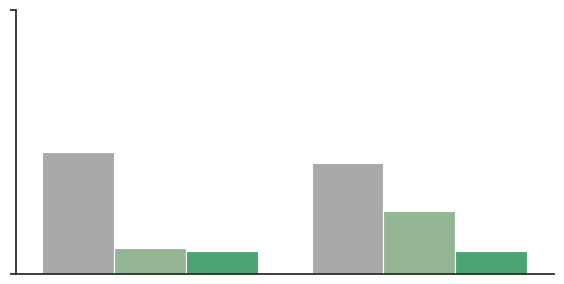

In [66]:
fig = model_comparison_barplot(
    alpha_delta_summary_all_sites,
    figsize=(5.8, 3),
    mode_color_scheme=summary_colors,
    show_bar_values=False,
    show_axes_labels_values=False,
    show_legend=False,
    bar_number_size=12,
    axes_number_size=12,
    axes_label_size=12,
)

In [67]:
fig.savefig(
    "../../documents/plots/alpha_delta_all_pairs.svg",
    format="svg",
    transparent=True,
)

## Fig 2d) Comparing only to reference sites

In [68]:
# Produce dicts of model and mode dataframes from the prediction dfs
alpha_delta_results_ref_only = estimate_delta_predictions(
    state_pred_dfs={
        "LMM alpha": lmm_alpha_results,
        "BHM alpha": bhm_alpha_results,
    },
    run_folders={
        "LMM alpha": lmm_alpha_folders,
        "BHM alpha": bhm_alpha_folders,
    },
    grouping_level="SSB",
    reference_comparison_only=True,
)

# Summary table
alpha_delta_summary_ref_only = build_model_performance_summary(
    alpha_delta_results_ref_only
)

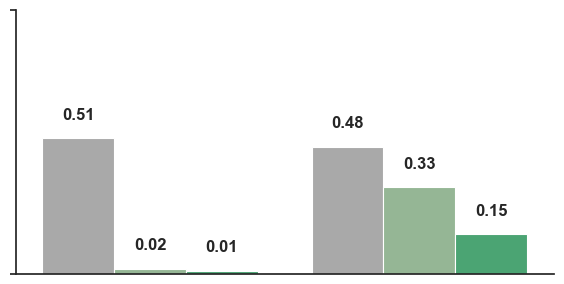

In [72]:
fig = model_comparison_barplot(
    alpha_delta_summary_ref_only,
    figsize=(5.8, 3),
    mode_color_scheme=summary_colors,
    show_bar_values=True,
    show_axes_labels_values=False,
    show_legend=False,
    bar_number_size=12,
    axes_number_size=12,
    axes_label_size=12,
)

In [71]:
fig.savefig(
    "../../documents/plots/alpha_delta_ref_pairs.svg",
    format="svg",
    transparent=True,
)

## Model summary legend

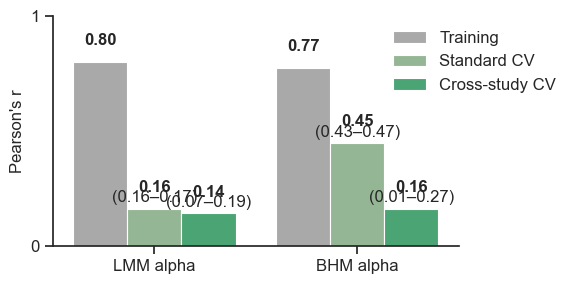

In [ ]:
fig = model_comparison_barplot(
    alpha_summary_results,
    figsize=(5.8, 3),
    mode_color_scheme=summary_colors,
    show_bar_values=True,
    show_axes_labels_values=True,
    show_legend=True,
    bar_number_size=12,
    axes_number_size=12,
    axes_label_size=12,
)
fig.savefig(
    "../../documents/plots/model_summary_legend.svg",
    format="svg",
    transparent=True,
)

# Figure 3: LMM alpha model deep dive 

## Model calibration plots

In [89]:
def basic_scatter_plot(
    df: pl.DataFrame,
    x_col: str,
    y_col: str,
    figsize: tuple[int, int],
    show_axes_labels_values: bool = True,
    show_metrics: bool = True,
    show_best_fit_line: bool = True,
    show_diagonal_ref_line: bool = True,
    show_zero_ref_line: bool = False,
    color: str = "steelblue",
    alpha: float = 0.4,
    point_size: int = 5,
    sample_frac: float = 1.0,
    poly_degree: int = 3,
    x_label: str = "Observed values",
    y_label: str = "Model predictions",
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
) -> plt.Figure:
    """
    Create a simple scatterplot comparing two arrays of variables, with
    optional sampling, polynomial best-fit line, and performance metrics.
    """
    # Extract numeric arrays and drop non-finite values
    x_array = df.get_column(x_col).to_numpy()
    y_array = df.get_column(y_col).to_numpy()

    mask = np.isfinite(x_array) & np.isfinite(y_array)
    x_valid = x_array[mask]
    y_valid = y_array[mask]

    # Compute metrics on the full valid data (not the sampled subset)
    pearson_r, _ = pearsonr(x_valid, y_valid)
    mae = float(np.mean(np.abs(x_valid - y_valid)))

    # Optional random subsampling (for plotting only)
    if (sample_frac is not None) and (0 < sample_frac < 1.0):
        n = len(x_valid)
        k = max(1, int(n * sample_frac))
        rng = np.random.default_rng(seed=42)
        idx = rng.choice(n, size=k, replace=False)
        x_plot = x_valid[idx]
        y_plot = y_valid[idx]
    else:
        x_plot, y_plot = x_valid, y_valid

    # Plot setup
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        x=x_plot,
        y=y_plot,
        color=color,
        alpha=alpha,
        s=point_size,
        ax=ax,
    )

    # Axis limits (if provided)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    # Diagonal 1:1 reference line (always shown)
    if show_diagonal_ref_line:
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            transform=ax.transAxes,
            color="black",
            linewidth=1.2,
            zorder=5,
        )

    # Optional reference line at zero
    if show_zero_ref_line:
        ax.axhline(
            y=0,
            linestyle=":",
            color="black",
            linewidth=1.2,
            zorder=4,
        )

    # Optional polynomial best-fit line
    if show_best_fit_line and len(x_plot) >= poly_degree + 1:
        coefs = np.polyfit(x_plot, y_plot, deg=poly_degree)
        x_vals = np.linspace(*sorted(ax.get_xlim()), 200)
        y_vals = np.polyval(coefs, x_vals)
        ax.plot(
            x_vals,
            y_vals,
            linestyle="-",
            color="firebrick",
            linewidth=2,
            zorder=6,
        )

    # Optional metrics annotation
    if show_metrics:
        ax.text(
            0.03,
            0.97,
            f"r = {pearson_r:.2f}\nMAE = {mae:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=axes_label_size,
        )

    # Axes labels & tick formatting
    if show_axes_labels_values:
        ax.set_xlabel(x_label, fontsize=axes_label_size)
        ax.set_ylabel(y_label, fontsize=axes_label_size)
        ax.tick_params(axis="both", labelsize=axes_number_size)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(
            axis="both",
            which="both",
            labelbottom=False,
            labelleft=False,
        )

    fig.tight_layout()
    return fig

## 3a) Training 

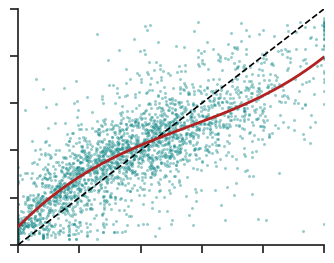

In [510]:
fig = basic_scatter_plot(
    df=lmm_alpha_results["Training"],
    x_col="Observed",
    y_col="Predicted_RE",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [511]:
fig.savefig(
    "../../documents/plots/lmm_alpha_scatter_train.svg", format="svg", transparent=True
)

## 3b) Standard CV

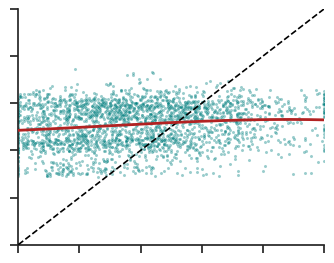

In [512]:
fig = basic_scatter_plot(
    df=lmm_alpha_results["Standard CV"],
    x_col="Observed",
    y_col="Predicted_FE",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [513]:
fig.savefig(
    "../../documents/plots/lmm_alpha_scatter_site.svg", format="svg", transparent=True
)

## 3c) Cross-study validation

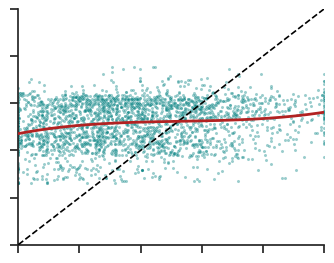

In [514]:
fig = basic_scatter_plot(
    df=lmm_alpha_results["Cross-study CV"],
    x_col="Observed",
    y_col="Predicted_FE",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [515]:
fig.savefig(
    "../../documents/plots/lmm_alpha_scatter_study.svg", format="svg", transparent=True
)

## Variance explained for different random effects structures 

In [489]:
def load_glmm_phi(
    run_folder: str,
    base_path: str = base_path,
    filename: str = "train_phi.json",
) -> float:
    phi_path = Path(base_path) / run_folder / "key_output" / filename
    with open(phi_path) as f:
        out = json.load(f)
    return float(out["phi"])

In [490]:
def calculate_r2_var_explained(
    df: pl.DataFrame,
    distribution: str = "gaussian",
    phi: float | None = None,
    eps: float = 1e-6,
) -> tuple[float, float]:
    """
    Compute marginal/conditional R2 for Gaussian and Beta mixed models.
    Uses latent-scale decomposition for Beta.
    """
    y = df.get_column("Observed").to_numpy()
    y_fe = df.get_column("Predicted_FE").to_numpy()
    y_re = df.get_column("Predicted_RE").to_numpy()

    if distribution == "gaussian":
        var_fe = np.var(y_fe, ddof=1)
        var_re = np.var(y_re - y_fe, ddof=1)
        var_residual = np.var(y - y_re, ddof=1)

    elif distribution == "beta":
        mu_fe = np.clip(y_fe, eps, 1 - eps)
        mu_re = np.clip(y_re, eps, 1 - eps)

        eta_fe = logit(mu_fe)
        eta_re = logit(mu_re)

        var_fe = np.var(eta_fe, ddof=1)
        var_re = np.var(eta_re - eta_fe, ddof=1)
        var_residual = np.mean(1.0 / ((1.0 + phi) * mu_re * (1.0 - mu_re)))

    denominator = var_fe + var_re + var_residual
    var_expl_fe = var_fe / denominator
    var_expl_re = (var_fe + var_re) / denominator

    return var_expl_fe, var_expl_re

In [491]:
def compute_r2_by_run(
    run_folders: dict[str, str],
    distribution: str = "beta",
    base_path: str = base_path,
    key_output_dirname: str = key_output_path,
    predictions_filename: str = "train_predictions.parquet",
) -> dict[str, tuple[float, float]]:
    results = {}
    base = Path(base_path)

    for run_name, folder in run_folders.items():
        df = pl.read_parquet(base / folder / key_output_dirname / predictions_filename)
        phi = (
            load_glmm_phi(folder, base_path=base_path)
            if distribution == "beta"
            else None
        )
        results[run_name] = calculate_r2_var_explained(
            df, distribution=distribution, phi=phi
        )

    return results

In [492]:
# Run calculations for LMM alpha models
lmm_alpha_re_structures = {
    "Study intercepts": "lmm_alpha_study_intercepts",
    "Study-block intercepts": "lmm_alpha_study_block_intercepts",
    "Study slopes": "lmm_alpha_train",
}

lmm_alpha_r2_dict = compute_r2_by_run(lmm_alpha_re_structures, distribution="beta")

## Fig 3d) Variance explained plot

In [421]:
def r2_stacked_barplot(
    r2_dictionary: dict[str, tuple[float, float]],
    figsize: tuple[int, int] = (6, 4),
    show_axes_labels: bool = True,
    show_bar_values: bool = True,
    show_legend: bool = True,
    colors: tuple[str, str] = ("steelblue", "yellowgreen"),
    alpha: float = 0.8,
    bar_number_size: int = 11,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
    wrap_labels_at: int | None = 12,
) -> plt.Figure:
    """
    Plot marginal and conditional R² as stacked bars. Marginal R² is the
    fixed-effects portion; the additional bar height shows variance explained
    by random effects.
    """
    # Extract model names and R² components
    models = list(r2_dictionary.keys())
    marginal_r2 = [r2_dictionary[m][0] for m in models]
    conditional_r2 = [r2_dictionary[m][1] for m in models]
    random_effect_r2 = [c - m for m, c in zip(marginal_r2, conditional_r2)]
    x = np.arange(len(models))

    # Plot setup
    fig, ax = plt.subplots(figsize=figsize)
    # Marginal component first
    ax.bar(
        x,
        height=marginal_r2,
        width=0.5,
        label="Marginal R²",
        color=colors[0],
        alpha=alpha,
    )
    # Random effect increment on top
    ax.bar(
        x,
        height=random_effect_r2,
        width=0.5,
        bottom=marginal_r2,
        label="Additional R² from random effects",
        color=colors[1],
        alpha=alpha,
    )

    # Add bar value labels
    if show_bar_values:
        for i in range(len(models)):
            # Marginal portion
            ax.text(
                x[i],
                marginal_r2[i] / 2,
                f"{marginal_r2[i]:.2f}",
                ha="center",
                va="center",
                fontsize=bar_number_size,
            )
            # Random effect increment
            ax.text(
                x[i],
                marginal_r2[i] + random_effect_r2[i] / 2,
                f"{random_effect_r2[i]:.2f}",
                ha="center",
                va="center",
                fontsize=bar_number_size,
            )
            # Total conditional R² at top
            ax.text(
                x[i],
                conditional_r2[i] + 0.015,
                f"{conditional_r2[i]:.2f}",
                ha="center",
                va="bottom",
                fontsize=bar_number_size,
            )

    # Wrap long x-axis labels if requested
    if wrap_labels_at is not None:
        xticklabels = [
            textwrap.fill(label, width=wrap_labels_at, break_long_words=False)
            for label in models
        ]
    else:
        xticklabels = models

    # Axes labels and ticks
    ax.set_yticks([0, 1])
    if show_axes_labels:
        ax.set_xticks(x)
        ax.set_xticklabels(xticklabels, fontsize=axes_label_size)
        ax.tick_params(axis="x", length=0)

        ax.set_ylim(0, 1.0)
        ax.set_yticklabels(["0", "1"], fontsize=axes_number_size)
        ax.tick_params(axis="y", length=5)

        ax.set_ylabel("Var. explained (R²)", fontsize=axes_label_size)
        ax.yaxis.set_label_coords(-0.07, 0.5)

    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.tick_params(
            axis="both",
            which="both",
            labelbottom=False,
            labelleft=False,
        )

    # Legend (optional)
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()

        # Extra legend element for total conditional R²
        cond_patch = Patch(
            facecolor="white",
            edgecolor="grey",
            label="= Conditional R² (total)",
            linewidth=1,
        )
        handles.append(cond_patch)
        labels.append("= Conditional R² (total)")

        ax.legend(
            handles=handles,
            labels=labels,
            fontsize=axes_label_size,
            edgecolor="none",
            loc="upper left",
            bbox_to_anchor=(0, 1),
            frameon=False,
        )

    fig.tight_layout()
    return fig

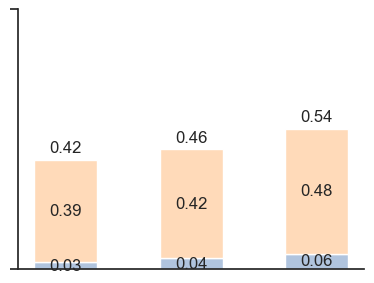

In [518]:
fig = r2_stacked_barplot(
    r2_dictionary=lmm_alpha_r2_dict,
    figsize=(3.9, 3),  # figsize=(3.5, 3),
    show_axes_labels=False,
    show_bar_values=True,
    show_legend=False,
    colors=(color_scheme["fixed_eff"], color_scheme["random_eff"]),
    alpha=1,
    bar_number_size=12,
    axes_label_size=12,
    axes_number_size=12,
    wrap_labels_at=12,
)

In [517]:
fig.savefig(
    "../../documents/plots/lmm_alpha_var_explained.svg", format="svg", transparent=True
)

## Effect size estimates

In [343]:
def extract_glmm_effects(
    model_path: str,
    re_lower_perc: float = 5,
    re_upper_perc: float = 95,
) -> dict[str, dict[str, float]]:
    """
    Load a glmmTMB model (.rds) and extract fixed effects plus optional
    study-level random slope variation summaries.

    Effects are returned on the response scale as delta(mu) from baseline.
    """
    model_path = str(model_path)

    r_code = """
      args <- commandArgs(trailingOnly = TRUE)
      model_path <- args[[1]]
      out_path <- args[[2]]
      re_lower <- as.numeric(args[[3]])
      re_upper <- as.numeric(args[[4]])

      suppressPackageStartupMessages({
        library(glmmTMB)
        library(jsonlite)
      })

      model <- readRDS(model_path)
      coef_tab <- summary(model)$coefficients$cond
      fixef_cond <- fixef(model)$cond

      intercept <- if ("(Intercept)" %in% names(fixef_cond)) {
        as.numeric(fixef_cond[["(Intercept)"]])
      } else {
        0
      }

      linkinv_func <- model$family$linkinv
      if (!is.function(linkinv_func)) {
        # Fallback for beta/logit models
        linkinv_func <- make.link("logit")$linkinv
      }

      to_response_delta <- function(delta_eta) {
        as.numeric(linkinv_func(intercept + delta_eta) - linkinv_func(intercept))
      }

      # Try model-based CIs first; fall back to Wald CIs.
      ci_mat <- tryCatch(
        suppressMessages(confint(model, parm = "beta_", level = 0.95)),
        error = function(e) NULL
      )

      get_ci <- function(term) {
        est <- as.numeric(coef_tab[term, "Estimate"])
        se <- as.numeric(coef_tab[term, "Std. Error"])
        ci_low <- est - 1.96 * se
        ci_up <- est + 1.96 * se

        if (!is.null(ci_mat)) {
          rn <- rownames(ci_mat)
          idx <- which(rn %in% c(paste0("cond.", term), term))
          if (length(idx) > 0) {
            ci_low <- as.numeric(ci_mat[idx[1], 1])
            ci_up <- as.numeric(ci_mat[idx[1], 2])
          }
        }
        c(ci_low, ci_up)
      }

      effect_dict <- list()

      re_cond <- tryCatch(ranef(model)$cond, error = function(e) NULL)
      re_study <- NULL
      if (!is.null(re_cond) && "SS" %in% names(re_cond)) {
        re_study <- as.data.frame(re_cond$SS)
      }

      for (term in names(fixef_cond)) {
        if (term == "(Intercept)") next

        est_eta <- as.numeric(fixef_cond[[term]])
        ci_eta <- get_ci(term)

        ci_resp <- sort(c(
          to_response_delta(ci_eta[1]),
          to_response_delta(ci_eta[2])
        ))

        info <- list(
          mean = to_response_delta(est_eta),
          ci_lower_2_5 = as.numeric(ci_resp[1]),
          ci_upper_97_5 = as.numeric(ci_resp[2])
        )

        if (!is.null(re_study) && term %in% colnames(re_study)) {
          deviations <- re_study[[term]]
          deviations <- deviations[!is.na(deviations)]
          if (length(deviations) > 1) {
            lower_eta <- est_eta + as.numeric(quantile(deviations, probs = re_lower / 100))
            upper_eta <- est_eta + as.numeric(quantile(deviations, probs = re_upper / 100))
            rs_resp <- sort(c(
              to_response_delta(lower_eta),
              to_response_delta(upper_eta)
            ))
            info$random_slope_lower <- as.numeric(rs_resp[1])
            info$random_slope_upper <- as.numeric(rs_resp[2])
          }
        }

        effect_dict[[term]] <- info
      }

      write_json(effect_dict, out_path, auto_unbox = TRUE)
      """

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)
        r_script_path = tmp_dir / "extract_glmmtmb_effects.R"
        out_json_path = tmp_dir / "effects.json"
        r_script_path.write_text(r_code)

        subprocess.run(
            [
                "Rscript",
                str(r_script_path),
                model_path,
                str(out_json_path),
                str(re_lower_perc),
                str(re_upper_perc),
            ],
            check=True,
        )

        effect_dict = json.loads(out_json_path.read_text())

    return effect_dict

In [522]:
def load_glmm_effects(
    run_folder: str,
    base_path: str = base_path,
    filename: str = "train_effects.json",
    reextract_from_model: bool = False,
    re_lower_perc: float = 5,
    re_upper_perc: float = 95,
) -> dict[str, dict[str, float]]:
    run_dir = Path(base_path) / run_folder

    if reextract_from_model:
        model_path = run_dir / "glmm_model.rds"
        return extract_glmm_effects(
            str(model_path),
            re_lower_perc=re_lower_perc,
            re_upper_perc=re_upper_perc,
        )

    effects_path = run_dir / "key_output" / filename
    with open(effects_path) as f:
        return json.load(f)

In [ ]:
# Get the GLMM alpha baseline model
lmm_alpha_train_folder = lmm_alpha_folders["Training"]

# Extract fixed and random effects
lmm_alpha_effects = load_glmm_effects(
    run_folder=lmm_alpha_train_folder,
    reextract_from_model=True,
)

Warning messages:
1: In sqrt(diag(vv)) : NaNs produced
2: In sqrt(diag(object$cov.fixed)) : NaNs produced
3: In sqrt(diag(object$cov.fixed)) : NaNs produced


In [345]:
def lmm_effects_forest_plot(
    effect_dict: dict[str, dict[str, float]],
    re_percentiles: tuple[float, float] = (5, 95),
    figsize: tuple[int, int] = (6, 4),
    show_mean_values: bool = True,
    show_axes_labels_values: bool = True,
    show_legend: bool = True,
    colors: tuple[str, str] = ("steelblue", "yellowgreen"),
    alpha: float = 0.8,
    mean_label_size: int = 11,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
    ci_method: str = "Wald",
) -> plt.Figure:
    """
    Forest plot of LMM fixed effects with 95% CI, optionally showing random
    slope percentile ranges if available.
    """
    # Extract parameter names and formatted labels
    param_names = list(effect_dict.keys())
    y_pos = np.arange(len(param_names))

    means = [effect_dict[p]["mean"] for p in param_names]
    ci_lows = [effect_dict[p]["ci_lower_2_5"] for p in param_names]
    ci_highs = [effect_dict[p]["ci_upper_97_5"] for p in param_names]

    # Set up plot
    fig, ax = plt.subplots(figsize=figsize)
    # Reference vertical zero line
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)

    # Random slope ranges (if included)
    for i, p in enumerate(param_names):
        eff = effect_dict[p]
        if "random_slope_lower" in eff and "random_slope_upper" in eff:
            ax.hlines(
                y=y_pos[i],
                xmin=eff["random_slope_lower"],
                xmax=eff["random_slope_upper"],
                color=colors[1],
                linewidth=3,
                alpha=alpha,
                label=(
                    f"Study slope range ({re_percentiles[0]}/{re_percentiles[1]})"
                    if i == 0
                    else ""
                ),
            )

    # 95% CI bars on the fixed effects
    ax.hlines(
        y=y_pos,
        xmin=ci_lows,
        xmax=ci_highs,
        color=colors[0],
        linewidth=5,
        alpha=alpha,
        label=f"95% CI ({ci_method})",
    )

    # Mean points
    ax.plot(
        means,
        y_pos,
        "o",
        markersize=8,
        color=colors[0],
        alpha=alpha,
        label="Fixed effect mean",
    )

    # Optional value labels
    if show_mean_values:
        for i, (m, lo, hi) in enumerate(zip(means, ci_lows, ci_highs)):
            star = "*" if lo > 0 or hi < 0 else ""
            ax.text(
                m,
                y_pos[i] - 0.1,
                f"{m:.2f}{star}",
                ha="center",
                va="bottom",
                fontsize=mean_label_size,
            )

    # Y-axis formatting
    ax.invert_yaxis()
    ax.set_yticks(y_pos)

    if show_axes_labels_values:
        ax.set_yticklabels(param_names, fontsize=axes_label_size)
        ax.tick_params(axis="x", labelsize=axes_number_size)
    else:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Legend (optional)
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        # Remove duplicates while preserving order
        seen = set()
        unique = []
        for h, l in zip(handles, labels):
            if l not in seen and l != "":
                unique.append((h, l))
                seen.add(l)
        if unique:
            ax.legend(
                [h for h, _ in unique],
                [l for _, l in unique],
                fontsize=axes_number_size,
                loc="upper left",
                bbox_to_anchor=(1.02, 1),
                frameon=False,
            )

    fig.tight_layout()
    return fig

## 3e) Effect size plot

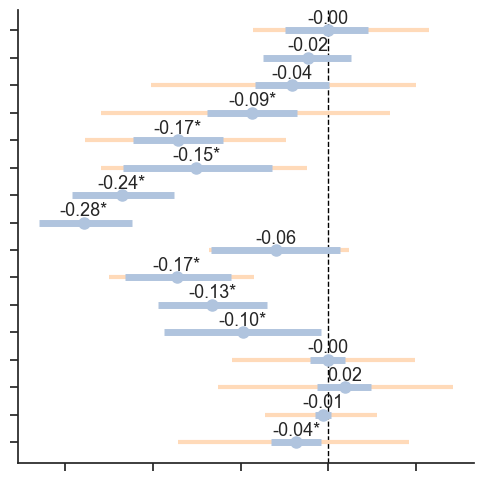

In [532]:
fig = lmm_effects_forest_plot(
    effect_dict=lmm_alpha_effects,
    re_percentiles=(5, 95),
    figsize=(5, 5),
    show_mean_values=True,
    show_axes_labels_values=False,
    show_legend=False,
    colors=(color_scheme["fixed_eff"], color_scheme["random_eff"]),
    alpha=1,
    mean_label_size=13,
    axes_label_size=12,
    axes_number_size=12,
    ci_method="Wald",
)

In [533]:
fig.savefig(
    "../../documents/plots/lmm_alpha_params.svg", format="svg", transparent=True
)

# Fig 4: BTM alpha interpolation deep dive

In [24]:
def load_all_test_fold_dfs(run_folder: str, n_folds: int = 5) -> pl.DataFrame:
    """Load all test dataframes, in order to get covariate information."""
    dfs = []
    for i in range(1, n_folds + 1):
        file_path = Path(base_path) / run_folder / f"test_fold_{i}.parquet"

        df = pl.read_parquet(file_path)
        dfs.append(df)

    return pl.concat(dfs, how="vertical")

In [25]:
def gower_knn_distances(
    query_x: np.ndarray,
    reference_x: np.ndarray,
    k: int = 5,
    max_reference_points: int | None = None,
    seed: int = 42,
    same_array: bool = False,
    selection: str = "nearest",
    metric: str = "median",
) -> np.ndarray:
    """
    Compute per-row Gower distance summaries to either:
    - k nearest reference points, or
    - k random reference points.
    """
    rng = np.random.default_rng(seed=seed)

    if max_reference_points is not None and len(reference_x) > max_reference_points:
        subset_idx = rng.choice(
            len(reference_x), size=max_reference_points, replace=False
        )
        ref = reference_x[subset_idx]
    else:
        ref = reference_x

    dist_matrix = gower.gower_matrix(query_x, ref)

    is_square = dist_matrix.shape[0] == dist_matrix.shape[1]
    if same_array and is_square:
        np.fill_diagonal(dist_matrix, np.nan if selection == "random" else np.inf)

    n_ref = dist_matrix.shape[1]
    k_eff = min(k, n_ref - 1 if (same_array and is_square) else n_ref)

    if selection == "nearest":
        selected = np.sort(dist_matrix, axis=1)[:, :k_eff]
    elif selection == "random":
        idx = rng.choice(n_ref, size=k_eff, replace=False)
        selected = dist_matrix[:, idx]
    # print(selected.shape)

    if metric == "median":
        aggregate = np.nanmedian(selected, axis=1)
    elif metric == "mean":
        aggregate = np.nanmean(selected, axis=1)

    # print(aggregate.shape)
    return aggregate

In [26]:
def compute_covariate_gower_per_group(
    df: pl.DataFrame,
    group_col: str,
    covariate_cols: list[str],
    k_neighbors: int = 10,
    selection: str = "random",
    metric: str = "median",
) -> pl.DataFrame:
    """Compute Gower homogeneity metrics (mean/median/std) for each group,
    based on the specified covariate columns.
    """
    groups = df[group_col].unique().to_list()
    records = []

    for g in groups:
        df_group = df.filter(pl.col(group_col) == g)
        x_group = df_group.select(covariate_cols).to_numpy()

        knn_vals = gower_knn_distances(
            query_x=x_group,
            reference_x=x_group,
            k=k_neighbors,
            same_array=True,
            max_reference_points=None,
            selection=selection,
            metric=metric,
        )

        # Get overall mean/median/std of the selected Gower distances for this group
        records.append(
            {
                group_col: g,
                "gower_mean": float(np.mean(knn_vals)),
                "gower_median": float(np.median(knn_vals)),
                "gower_std": float(np.std(knn_vals)),
            }
        )

    return pl.DataFrame(records)

In [27]:
def compute_outlier_proportions_per_group(
    df_joined: pl.DataFrame,
    group_col: str,
    true_col: str,
) -> pl.DataFrame:
    """Compute proportion of outliers per group using IQR method."""

    # Compute IQR per group
    df_iqr = df_joined.group_by(group_col).agg(
        [
            pl.col(true_col).quantile(0.25).alias("q1"),
            pl.col(true_col).quantile(0.75).alias("q3"),
        ]
    )
    df_iqr = df_iqr.with_columns((pl.col("q3") - pl.col("q1")).alias("iqr"))
    df_iqr = df_iqr.with_columns(
        [
            (pl.col("q1") - pl.col("iqr")).alias("lower_1_threshold"),
            (pl.col("q3") + pl.col("iqr")).alias("upper_1_threshold"),
            (pl.col("q1") - 1.5 * pl.col("iqr")).alias("lower_1_5_threshold"),
            (pl.col("q3") + 1.5 * pl.col("iqr")).alias("upper_1_5_threshold"),
        ]
    )

    # Join thresholds back to full df to check outliers
    df_with_thresholds = df_joined.join(df_iqr, on=group_col, how="left")

    # Flag outliers
    df_with_flags = df_with_thresholds.with_columns(
        [
            (
                (pl.col(true_col) < pl.col("lower_1_5_threshold"))
                | (pl.col(true_col) > pl.col("upper_1_5_threshold"))
            ).alias("is_outlier_1_5"),
            (
                (pl.col(true_col) < pl.col("lower_1_threshold"))
                | (pl.col(true_col) > pl.col("upper_1_threshold"))
            ).alias("is_outlier_1"),
        ]
    )

    # Compute proportion of outside values and outliers per group
    df_outliers = df_with_flags.group_by(group_col).agg(
        [
            pl.col("is_outlier_1_5").mean().alias("prop_outliers_1_5"),
            pl.col("is_outlier_1_5").sum().alias("n_outliers_1_5"),
            pl.col("is_outlier_1").mean().alias("prop_outliers_1"),
            pl.col("is_outlier_1").sum().alias("n_outliers_1"),
        ]
    )

    return df_outliers

In [28]:
def create_hierarchical_groups_in_predicts_data(
    df_predicts: pl.DataFrame,
) -> pl.DataFrame:
    """
    Add species group to the original PREDICTS data and combine this with
    biomes, to recreate the groupings used in the model. This is required for
    the next step.
    """

    # Recreate species groupings from codebase
    df_predicts = df_predicts.with_columns(
        [
            pl.when(pl.col("Phylum") == "Arthropoda")
            .then(  # Split between insects and other arthropods
                pl.when(pl.col("Class") == "Insecta")
                .then(pl.lit("Insecta"))
                .otherwise(pl.lit("Other Arthropoda"))
            )
            .when(pl.col("Phylum") == "Chordata")
            .then(  # Split birds and mammals
                pl.when(pl.col("Class").is_in(["Aves", "Mammalia"]))
                .then(pl.col("Class"))  # Combine amphibians and reptiles
                .when(pl.col("Class").is_in(["Amphibia", "Reptilia"]))
                .then(pl.lit("Amphibia_Reptilia"))
                .otherwise(pl.lit("Other Chordata"))
            )
            .when(pl.col("Phylum") == "Tracheophyta")
            .then(pl.lit("Tracheophyta"))  # Keep all vascular plants as one group
            .when(pl.col("Kingdom") == "Fungi")  # No splits due to little data
            .then(pl.lit("Fungi"))
            .otherwise(pl.lit("Other ") + pl.col("Kingdom"))  # Other animals and plants
            .alias("Species group")
        ]
    )

    return df_predicts

In [29]:
def compute_n_taxa_per_group(
    df_joined: pl.DataFrame,
    group_col: str,
) -> pl.DataFrame:
    """Compute number of unique taxa per group at the specified taxonomic rank."""
    df_predicts = pl.read_parquet("../../data/PREDICTS/merged_data.parquet")

    # Recreate hierarchical groups in the PREDICTS data
    df_predicts = create_hierarchical_groups_in_predicts_data(df_predicts)

    # Get group column from df_joined
    df_predicts = df_predicts.join(
        df_joined.select(["SSBS", group_col]), on="SSBS", how="left"
    )

    # Count unique taxa (e.g. orders) per group
    df_taxon_counts = df_predicts.group_by(group_col).agg(
        [
            pl.col("Order").n_unique().alias("n_orders"),
            pl.col("Family").n_unique().alias("n_families"),
            pl.col("Genus").n_unique().alias("n_genera"),
            pl.col("Species").n_unique().alias("n_species"),
        ]
    )

    return df_taxon_counts

In [30]:
def compute_deepdive_summary_per_group(
    df_pred: pl.DataFrame,
    df_covars: pl.DataFrame,
    run_folder: str,
    group_col: str,
    pred_col: str,
    covariate_cols: list[str],
    true_col: str = "Observed",
    k_neighbors: int = 10,
    gower_selection: str = "nearest",
    gower_metric: str = "median",
) -> pl.DataFrame:
    """
    Join predictions with site info (on SSBS), then per stratum compute various
    metrics for analysis.
    """
    df_site_info = read_site_info_parquet(run_folder)
    df_joined = df_pred.join(df_site_info, on="SSBS", how="left")

    if group_col == "Final_hierarchical_group":
        df_joined = df_joined.filter(pl.col("Final_hierarchical_level") != "Population")

    # Calculate correlation, unique sites, observations, studies per group
    df_stats = df_joined.group_by(group_col).agg(
        [
            pl.col("SSBS").n_unique().alias("n_sites"),
            pl.col("SSBS").len().alias("n_observations"),
            pl.col("SS").n_unique().alias("n_studies"),
            pl.col(true_col).std().alias("response_std"),
            pl.corr(true_col, pred_col).alias("Pearson_r"),
        ]
    )

    # Log transform counts
    df_stats = df_stats.with_columns(
        [
            pl.col("n_sites").log().alias("n_sites_log"),
            pl.col("n_observations").log().alias("n_observations_log"),
            pl.col("n_studies").log().alias("n_studies_log"),
        ]
    )

    # Calculate Gower homogeneity metrics per group
    df_gower = compute_covariate_gower_per_group(
        df=df_covars,
        group_col=group_col,
        covariate_cols=covariate_cols,
        k_neighbors=k_neighbors,
        selection=gower_selection,
        metric=gower_metric,
    )

    # Calculate proportion of outlier values
    df_outliers = compute_outlier_proportions_per_group(
        df_joined, group_col=group_col, true_col=true_col
    )

    # Count the number of taxonomic units per group
    df_taxa = compute_n_taxa_per_group(df_joined, group_col=group_col)

    # Merge with the rest
    df_out = (
        df_stats.join(df_outliers, on=group_col, how="left")
        .join(df_gower, on=group_col, how="left")
        .join(df_taxa, on=group_col, how="left")
        .sort(group_col)
    )

    return df_out

In [73]:
# Load covariate data for BHM alpha standard CV run
run_folder = bhm_alpha_folders["Standard CV"]
bhm_alpha_covariate_df = load_all_test_fold_dfs(run_folder)

bhm_alpha_covariates = [
    "Primary vegetation_Light use",
    "Primary vegetation_Intense use",
    "Secondary vegetation_Minimal use",
    "Secondary vegetation_Light use",
    "Secondary vegetation_Intense use",
    "Cropland_Minimal use",
    "Cropland_Light use",
    "Cropland_Intense use",
    "Pasture_Minimal use",
    "Pasture_Light use",
    "Pasture_Intense use",
    "Urban_All uses",
    "Pop_density_1km_log",
    "Pop_density_50km_log",
    "Road_density_1km_log",
    "Road_density_50km_log",
    "Annual_mean_temp_1km",
    "Temp_seasonality_1km",
    "Annual_precip_1km",
    "Precip_seasonality_1km",
    "Elevation_1km",
    "Elevation_10km",
    "Terrain_roughness_1km",
    "Terrain_roughness_10km",
]

# BHM alpha standard CV
bhm_alpha_group_deepdive_std_cv = compute_deepdive_summary_per_group(
    df_pred=bhm_alpha_results["Standard CV"],
    df_covars=bhm_alpha_covariate_df,
    run_folder=run_folder,
    group_col="Final_hierarchical_group",
    covariate_cols=bhm_alpha_covariates,
    pred_col="Predicted",
    k_neighbors=10,
    gower_selection="nearest",
    gower_metric="median",
)

## Fig 4a) Distribution of group-level accuracies

In [33]:
def plot_histogram(
    df: pl.DataFrame,
    data_col: str,
    bins: int = 50,
    alpha: float = 0.7,
    color: str = "steelblue",
    figsize: tuple = (5, 4),
    axes_numbers_size: int = 12,
    axes_label_size: int = 12,
    show_axes_labels: bool = False,
    show_axes_numbers: bool = True,
) -> plt.Figure:
    # Extract data as numpy array
    data_array = df.select(pl.col(data_col)).to_series().to_numpy()

    # Create fig and ax
    fig, ax = plt.subplots(figsize=figsize)

    # Histogram
    sns.histplot(
        data_array,
        bins=bins,
        kde=False,
        ax=ax,
        color=color,
        alpha=alpha,
    )

    # Axis labels
    if not show_axes_labels:
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.set_xlabel(data_col, fontsize=axes_label_size)
        ax.set_ylabel("Frequency", fontsize=axes_label_size)

    # Axis numbers
    if show_axes_numbers:
        ax.tick_params(axis="x", labelsize=axes_numbers_size)
        ax.tick_params(axis="y", labelsize=axes_numbers_size)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.tight_layout()
    return fig

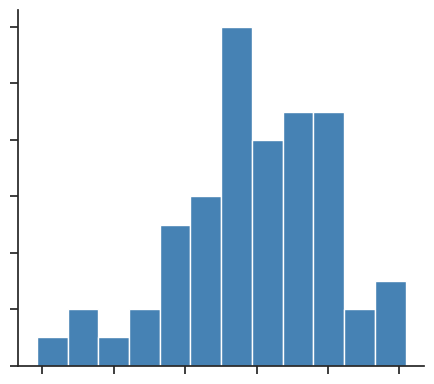

In [75]:
fig = plot_histogram(
    bhm_alpha_group_deepdive_std_cv,
    data_col="Pearson_r",
    bins=12,
    alpha=1,
    color="steelblue",
    figsize=(4.5, 4),
    axes_numbers_size=12,
    axes_label_size=12,
    show_axes_labels=False,
    show_axes_numbers=False,
)

In [76]:
fig.savefig(
    "../../documents/plots/bhm_alpha_group_acc_distr.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

In [77]:
# Get min and max Pearson r
min_r = float(bhm_alpha_group_deepdive_std_cv["Pearson_r"].min())
max_r = float(bhm_alpha_group_deepdive_std_cv["Pearson_r"].max())
mean_r = float(bhm_alpha_group_deepdive_std_cv["Pearson_r"].mean())
print(min_r, max_r, mean_r)

-0.21552051205993475 0.8173623849310313 0.39144541207250644


## Fig 4b) Regression coefficient forest plot

In [80]:
def ols_forest_plot(
    model,
    var_names,
    include_intercept: bool = False,
    figsize: tuple[int, int] = (6, 4),
    show_mean_values: bool = True,
    show_axes_labels_values: bool = True,
    show_legend: bool = True,
    color: str = "steelblue",
    alpha: float = 0.8,
    mean_label_size: int = 11,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
    ci_method: str = "Wald",
    ci_alpha: float = 0.05,
) -> plt.Figure:
    """
    Forest plot of standardized OLS effects with (1-ci_alpha)% CI.
    Assumes model was fit with sm.add_constant(Xz) and var_names matches Xz
    column order.
    """

    names = ["Intercept"] + list(var_names)
    params = np.asarray(model.params)
    ci = np.asarray(model.conf_int(alpha=ci_alpha))

    rows = []
    for name, est, (lo, hi) in zip(names, params, ci):
        if (name == "Intercept") and (not include_intercept):
            continue
        rows.append((name, float(est), float(lo), float(hi)))

    # Sort rows by effect size
    rows.sort(key=lambda r: r[1], reverse=False)

    labels = [(r[0]) for r in rows]
    means = np.array([r[1] for r in rows])
    ci_lows = np.array([r[2] for r in rows])
    ci_highs = np.array([r[3] for r in rows])
    y_pos = np.arange(len(rows))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)

    ax.hlines(
        y=y_pos,
        xmin=ci_lows,
        xmax=ci_highs,
        color=color,
        linewidth=5,
        alpha=alpha,
        label=f"{int(round((1-ci_alpha)*100))}% CI ({ci_method})",
    )
    ax.plot(
        means,
        y_pos,
        "o",
        markersize=8,
        color=color,
        alpha=alpha,
        label="Effect estimate",
    )

    if show_mean_values:
        for i, (m, lo, hi) in enumerate(zip(means, ci_lows, ci_highs)):
            star = "*" if (lo > 0) or (hi < 0) else ""
            ax.text(
                m,
                y_pos[i] - 0.1,
                f"{m:.2f}{star}",
                ha="center",
                va="bottom",
                fontsize=mean_label_size,
            )

    ax.invert_yaxis()
    ax.set_yticks(y_pos)

    if show_axes_labels_values:
        ax.set_yticklabels(labels, fontsize=axes_label_size)
        ax.tick_params(axis="x", labelsize=axes_number_size)
    else:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    if show_legend:
        handles, lab = ax.get_legend_handles_labels()
        seen, uniq = set(), []
        for h, l in zip(handles, lab):
            if l and l not in seen:
                uniq.append((h, l))
                seen.add(l)
        if uniq:
            ax.legend(
                [h for h, _ in uniq],
                [l for _, l in uniq],
                fontsize=axes_number_size,
                loc="upper left",
                bbox_to_anchor=(1.02, 1),
                frameon=False,
            )

    fig.tight_layout()
    return fig

In [78]:
y = bhm_alpha_group_deepdive_std_cv.get_column("Pearson_r").to_numpy()

X_df = bhm_alpha_group_deepdive_std_cv.select(
    [
        "n_studies_log",
        "n_sites_log",
        "response_std",
        "prop_outliers_1",
        "prop_outliers_1_5",
        "gower_median",
        "n_orders",
    ]
)

X_raw = X_df.to_numpy()
var_names = X_df.columns

# Standardize predictors
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=1)
Xz = (X_raw - X_mean) / X_std

# Fit
X = sm.add_constant(Xz)
model = sm.OLS(y, X).fit()

print(model.summary(xname=["Intercept"] + var_names))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     8.278
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.40e-07
Time:                        10:40:40   Log-Likelihood:                 29.506
No. Observations:                  60   AIC:                            -43.01
Df Residuals:                      52   BIC:                            -26.26
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3914      0.02

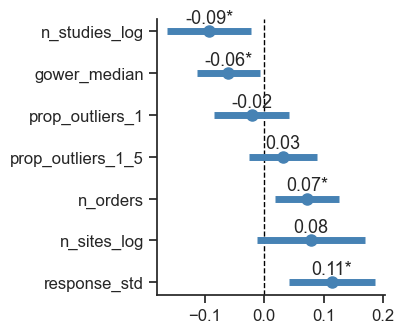

In [87]:
fig = ols_forest_plot(
    model,
    var_names,
    figsize=(4.2, 3.5),
    show_mean_values=True,
    show_axes_labels_values=True,
    show_legend=False,
    color="steelblue",
    alpha=1,
    mean_label_size=13,
    axes_label_size=12,
    axes_number_size=12,
    ci_method="Wald",
    ci_alpha=0.05,
)

In [86]:
fig.savefig(
    "../../documents/plots/bhm_alpha_group_acc_drivers.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

# Figure 5: BHM alpha model deep dive

## Model calibration plots

## 5a) Training

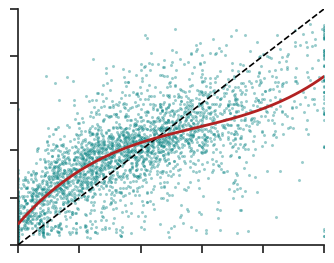

In [91]:
fig = basic_scatter_plot(
    df=bhm_alpha_results["Training"],
    x_col="Observed",
    y_col="Predicted",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [92]:
fig.savefig(
    "../../documents/plots/bhm_alpha_scatter_train.svg", format="svg", transparent=True
)

## 4b) Standard CV

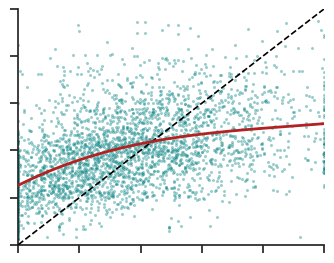

In [94]:
fig = basic_scatter_plot(
    df=bhm_alpha_results["Standard CV"],
    x_col="Observed",
    y_col="Predicted",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [95]:
fig.savefig(
    "../../documents/plots/bhm_alpha_scatter_site.svg", format="svg", transparent=True
)

## 4c) Cross-study validation

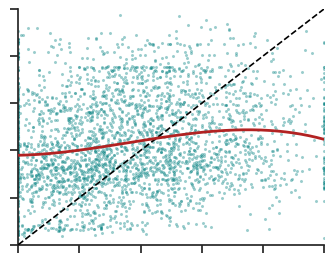

In [97]:
fig = basic_scatter_plot(
    df=bhm_alpha_results["Cross-study CV"],
    x_col="Observed",
    y_col="Predicted",
    figsize=(3.5, 2.8),
    show_axes_labels_values=False,
    show_metrics=False,
    show_best_fit_line=True,
    color=color_scheme["calibration"],
    alpha=0.4,
    point_size=5,
    sample_frac=0.1,
    poly_degree=3,
    x_label="Observed",
    y_label="Predicted",
    xlim=(0, 1),
    ylim=(0, 1),
    axes_label_size=12,
    axes_number_size=12,
)

In [98]:
fig.savefig(
    "../../documents/plots/bhm_alpha_scatter_study.svg", format="svg", transparent=True
)

## Analysis of distribution shifts

In [99]:
def get_train_test_data_per_fold(
    run_folder: str,
    base_path: str = base_path,
    key_output_dirname: str = "key_output",
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """
    Load CV fold prediction files and extract observed values per fold.

    Expects files:
      <run_folder>/<key_output_dirname>/train_predictions_fold_*.parquet
      <run_folder>/<key_output_dirname>/test_predictions_fold_*.parquet
    """
    key_output_dir = Path(base_path) / run_folder / key_output_dirname

    train_files = sorted(
        key_output_dir.glob("train_predictions_fold_*.parquet"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )
    test_files = sorted(
        key_output_dir.glob("test_predictions_fold_*.parquet"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )

    train_y_list: list[np.ndarray] = []
    test_y_list: list[np.ndarray] = []

    for train_path, test_path in zip(train_files, test_files):
        df_train = pl.read_parquet(train_path)
        df_test = pl.read_parquet(test_path)
        train_y_list.append(df_train.get_column("Observed").to_numpy())
        test_y_list.append(df_test.get_column("Observed").to_numpy())

    return train_y_list, test_y_list

In [100]:
# Standard CV: Get observed data for train and test sets
bhm_alpha_train_y_std_cv, bhm_alpha_test_y_std_cv = get_train_test_data_per_fold(
    run_folder=bhm_alpha_folders["Standard CV"]
)

# Get Pearson r values per fold from the model performance summary
bhm_alpha_r_std_cv = (
    alpha_summary_results.filter(
        (pl.col("Model") == "BHM alpha") & (pl.col("Eval type") == "Standard CV")
    )
    .select(pl.nth(range(5, 10)))
    .to_numpy()
    .flatten()
    .tolist()
)

In [101]:
# Cross-study CV: Get observed data for train and test sets
bhm_alpha_train_y_cross_study, bhm_alpha_test_y_cross_study = (
    get_train_test_data_per_fold(run_folder=bhm_alpha_folders["Cross-study CV"])
)

# Get Pearson r values per fold from the model performance summary
bhm_alpha_r_cross_study = (
    alpha_summary_results.filter(
        (pl.col("Model") == "BHM alpha") & (pl.col("Eval type") == "Cross-study")
    )
    .select(pl.nth(range(5, 10)))
    .to_numpy()
    .flatten()
    .tolist()
)

In [102]:
def foldwise_kde_subplots(
    train_data_list: list[np.ndarray],
    test_data_list: list[np.ndarray],
    test_r_list: list[float],
    figsize: tuple[int, int] = (4, 3),
    show_axes_labels_values: bool = True,
    show_fold_labels: bool = True,
    show_r_values: bool = False,
    show_legend: bool = True,
    xlabel: str = "",
    colors: dict[str, str] = {"train": "steelblue", "test": "darkorange"},
    alpha: float = 0.8,
    r_label_size: int = 11,
    axes_label_size: int = 11,
    axes_number_size: int = 11,
    xlim: tuple[float, float] | None = None,
) -> plt.Figure:
    """
    Plot fold-wise KDE curves for train and test data distributions using
    stacked subplots.
    """
    num_folds = len(train_data_list)

    # Plot setup
    fig, axs = plt.subplots(
        nrows=num_folds,
        ncols=1,
        figsize=(figsize[0], figsize[1] * num_folds),
        sharex=True,
        gridspec_kw={"hspace": 0.1},
        constrained_layout=True,
    )

    # Determine KDE range from all folds
    all_values = np.concatenate(train_data_list + test_data_list)
    vmin, vmax = all_values.min(), all_values.max()
    x_pad = 0.05 * (vmax - vmin)
    x_range = (vmin - x_pad, vmax + x_pad)

    for i in range(num_folds):
        ax = axs[i]

        # Plot training data KDE
        sns.kdeplot(
            train_data_list[i],
            ax=ax,
            color=colors["train"],
            fill=False,
            alpha=alpha,
            linewidth=2,
            bw_adjust=1.2,
        )

        # Plot testing data KDE
        sns.kdeplot(
            test_data_list[i],
            ax=ax,
            color=colors["test"],
            fill=False,
            alpha=alpha,
            linewidth=2,
            bw_adjust=1.2,
        )

        if xlim is not None:
            ax.set_xlim(*xlim)
        else:
            ax.set_xlim(*x_range)

        # Label fold plots
        if show_fold_labels:
            ax.set_ylabel(
                f"Fold {i+1}", fontsize=axes_label_size, rotation=0, labelpad=30
            )
        else:
            ax.set_ylabel("")

        # Hide KDE y-axis ticks
        ax.set_yticks([])
        ax.set_yticklabels([])

        # r-value annotation
        if test_r_list is not None and show_r_values:
            ax.text(
                0.95,
                0.5,
                f"r = {test_r_list[i]:.2f}",
                transform=ax.transAxes,
                ha="left",
                va="center",
                fontsize=r_label_size,
            )

        # x-axis label rules
        if i == num_folds - 1 and show_axes_labels_values:
            ax.set_xlabel(xlabel, fontsize=axes_label_size)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        ax.tick_params(axis="x", labelsize=axes_number_size)

        # Remove unnecessary spines
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

    # Legend
    if show_legend:
        legend_handles = [
            Line2D([0], [0], color=colors["train"], lw=2, label="Train"),
            Line2D([0], [0], color=colors["test"], lw=2, label="Test"),
        ]
        fig.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=axes_label_size,
            frameon=False,
            bbox_to_anchor=(1.12, 1.05),
        )

    return fig

## Distribution shift in covariates

In [103]:
def compute_gower_distances_train_test(
    run_folder: str,
    covariate_cols: list[str],
    base_path: str = base_path,
    k_neighbors: int = 5,
    max_train_points: int = 1000,
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """Compute fold-wise train/test kNN Gower distances from saved CV folds."""
    run_dir = Path(base_path) / run_folder

    # Get the list of train/test fold dataframes
    train_files = sorted(
        run_dir.glob("train_fold_*.parquet"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )
    test_files = sorted(
        run_dir.glob("test_fold_*.parquet"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )

    train_dist_list = []
    test_dist_list = []

    for train_path, test_path in zip(train_files, test_files):
        df_train = pl.read_parquet(train_path)
        df_test = pl.read_parquet(test_path)

        train_x = df_train.select(covariate_cols).to_numpy()
        test_x = df_test.select(covariate_cols).to_numpy()

        train_dist_list.append(
            gower_knn_distances(
                query_x=train_x,
                reference_x=train_x,
                k=k_neighbors,
                max_reference_points=max_train_points,
                same_array=True,
                selection="nearest",
                metric="median",
            )
        )
        test_dist_list.append(
            gower_knn_distances(
                query_x=test_x,
                reference_x=train_x,
                k=k_neighbors,
                max_reference_points=max_train_points,
                same_array=False,
                selection="nearest",
                metric="median",
            )
        )

    return train_dist_list, test_dist_list

In [104]:
# Compute Gower distances for BHM alpha standard CV
run_folder = bhm_alpha_folders["Standard CV"]
(
    bhm_alpha_train_dist_std_cv,
    bhm_alpha_test_dist_std_cv,
) = compute_gower_distances_train_test(
    run_folder=run_folder,
    covariate_cols=bhm_alpha_covariates,
    k_neighbors=10,
    max_train_points=2000,
)

In [105]:
# Compute Gower distances for BHM alpha cross-study CV
run_folder = bhm_alpha_folders["Cross-study CV"]
(
    bhm_alpha_train_dist_cross_study,
    bhm_alpha_test_dist_cross_study,
) = compute_gower_distances_train_test(
    run_folder=run_folder,
    covariate_cols=bhm_alpha_covariates,
    k_neighbors=10,
    max_train_points=2000,
)

## Fig 5d) Standard CV

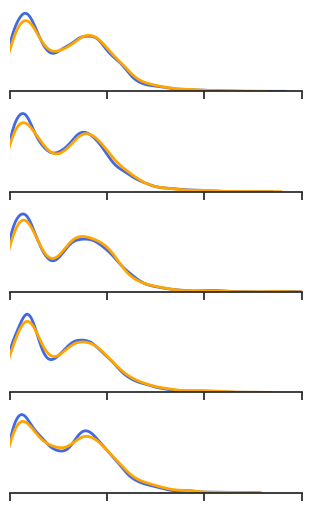

In [106]:
fig = foldwise_kde_subplots(
    train_data_list=bhm_alpha_train_dist_std_cv,
    test_data_list=bhm_alpha_test_dist_std_cv,
    test_r_list=bhm_alpha_r_std_cv,
    figsize=(3, 1),
    show_axes_labels_values=False,
    show_fold_labels=False,
    show_r_values=False,
    show_legend=False,
    xlabel="Distance to 5-NN in train data",
    colors={"train": color_scheme["train_line"], "test": color_scheme["test_line"]},
    alpha=1,
    r_label_size=12,
    axes_label_size=12,
    axes_number_size=12,
    xlim=(0, 0.15),
)

In [107]:
fig.savefig(
    "../../documents/plots/covariate_shift_site.svg", format="svg", transparent=True
)

## 5e) Cross-study CV

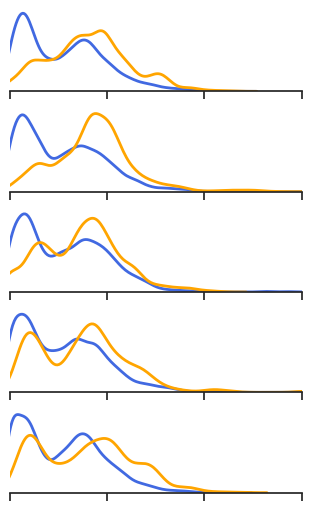

In [108]:
fig = foldwise_kde_subplots(
    train_data_list=bhm_alpha_train_dist_cross_study,
    test_data_list=bhm_alpha_test_dist_cross_study,
    test_r_list=bhm_alpha_r_cross_study,
    figsize=(3, 1),
    show_axes_labels_values=False,
    show_fold_labels=False,
    show_r_values=False,
    show_legend=False,
    xlabel="Distance to 5-NN in train data",
    colors={"train": color_scheme["train_line"], "test": color_scheme["test_line"]},
    alpha=1,
    r_label_size=12,
    axes_label_size=12,
    axes_number_size=12,
    xlim=(0, 0.15),
)

In [109]:
fig.savefig(
    "../../documents/plots/covariate_shift_study.svg", format="svg", transparent=True
)

## Distribution shifts in target variable 

## Fig 5f) Standard CV

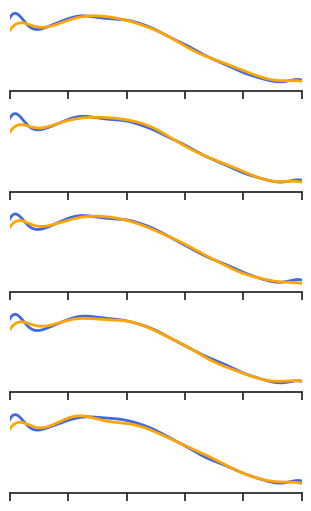

In [110]:
fig = foldwise_kde_subplots(
    train_data_list=bhm_alpha_train_y_std_cv,
    test_data_list=bhm_alpha_test_y_std_cv,
    test_r_list=bhm_alpha_r_std_cv,
    figsize=(3, 1),
    show_axes_labels_values=False,
    show_fold_labels=False,
    show_r_values=False,
    show_legend=False,
    xlabel="Alpha diversity value",
    colors={"train": color_scheme["train_line"], "test": color_scheme["test_line"]},
    alpha=1,
    r_label_size=12,
    axes_label_size=12,
    axes_number_size=12,
    xlim=(0, 1),
)

In [111]:
fig.savefig(
    "../../documents/plots/response_shift_site.svg", format="svg", transparent=True
)

## Fig 5g) Cross-study CV

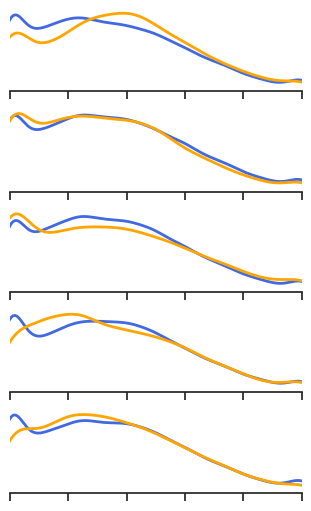

In [112]:
fig = foldwise_kde_subplots(
    train_data_list=bhm_alpha_train_y_cross_study,
    test_data_list=bhm_alpha_test_y_cross_study,
    test_r_list=bhm_alpha_r_cross_study,
    figsize=(3, 1),
    show_axes_labels_values=False,
    show_fold_labels=False,
    show_r_values=False,
    show_legend=False,
    xlabel="Alpha diversity value",
    colors={"train": color_scheme["train_line"], "test": color_scheme["test_line"]},
    alpha=1,
    r_label_size=12,
    axes_label_size=12,
    axes_number_size=12,
    xlim=(0, 1),
)

In [113]:
fig.savefig(
    "../../documents/plots/response_shift_study.svg", format="svg", transparent=True
)

# Figure 6: Maps of expected model accuracy per country 

## Calculate country stats

In [114]:
def build_country_lookup_table() -> pd.DataFrame:
    """
    Load Natural Earth country table with ADMIN and ISO_A3 information. Returns
    a pandas DataFrame with columns ['country_std', 'iso_a3'] that can be
    joined with model output data.
    """
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)[["ADMIN", "ISO_A3"]]
    world = world.rename(columns={"ADMIN": "country_std", "ISO_A3": "iso_a3"})

    return world

In [115]:
def add_iso_codes(
    df: pl.DataFrame,
) -> pl.DataFrame:
    """
    Add Natural Earth `iso_a3` and `country_std` codes to a DataFrame with
    model output data.

    Policy:
    - Use Natural Earth country definitions for mapping
    - Harmonize common country-name mismatches
    - Explicitly patch known Natural Earth ISO gaps (-99 or null)
    - Non-sovereign territories are either mapped to parent states or left
      missing by design (see overrides below)

    Returns
    -------
    pl.DataFrame
        Polars DataFrame with added `country_std` and `iso_a3` columns.
        Rows with unresolved ISO codes will not appear in maps unless
        handled downstream.
    """

    # ---- 1. Convert to pandas for merge compatibility ----
    df_pd = df.to_pandas()

    # ---- 2. Country-name harmonisation (Natural Earth alignment) ----
    name_overrides = {
        "United States": "United States of America",
        "Czech Republic": "Czechia",
        "Korea, Republic of": "South Korea",
        "United Republic of Tanzania": "Tanzania",
        "Cote d'Ivoire": "Côte d'Ivoire",
        "Sao Tome and Principe": "São Tomé and Príncipe",
        "Viet Nam": "Vietnam",
        "Lao People's Democratic Republic": "Laos",
        "Iran (Islamic Republic of)": "Iran",
        "Syrian Arab Republic": "Syria",
        "Côte d'Ivoire": "Ivory Coast",
        "Serbia": "Republic of Serbia",
        "Comoros": "Union of the Comoros",
    }
    df_pd["Country"] = df_pd["Country"].replace(name_overrides)

    # ---- 3. Natural Earth country lookup ----
    country_lookup = build_country_lookup_table()

    df_out = df_pd.merge(
        country_lookup,
        left_on="Country",
        right_on="country_std",
        how="left",
    )

    # ---- 4. ISO override policy ----
    # - Fix known Natural Earth '-99' cases
    # - Map selected territories to parent sovereign states
    iso_overrides = {
        # Natural Earth missing ISO (-99)
        "France": "FRA",
        "Norway": "NOR",
        # Territories / special cases
        "Hong Kong": "CHN",
        "French Guiana": "FRA",
        "Puerto Rico": "USA",
        "São Tomé and Príncipe": "STP",
        "Tanzania": "TZA",
        "Côte d'Ivoire": "CIV",
        "Union of the Comoros": "COM",
    }

    df_out["iso_a3"] = df_out["iso_a3"].where(
        (df_out["iso_a3"].notna()) & (df_out["iso_a3"] != "-99"),
        df_out["Country"].map(iso_overrides),
    )

    # ---- 5. Convert back to Polars ----
    return pl.DataFrame(df_out)

In [116]:
def calculate_country_stats(
    df_pred: pl.DataFrame,
    run_folder: str,
    pred_col: str,
    true_col: str = "Observed",
    clip: tuple[float, float] | None = None,
) -> pl.DataFrame:
    """
    Return one per-country dataframe containing:
      - number of unique studies
      - number of unique sites
      - Pearson's r between predictions and observations
      - ISO country codes (for plotting)
    """

    # Join predictions with site info
    df_site_info = read_site_info_parquet(run_folder).select(["SS", "SSBS", "Country"])
    df_merged = df_pred.join(df_site_info, on="SSBS", how="inner")

    # Per-country counts
    df_counts = df_merged.group_by("Country").agg(
        [
            pl.col("SS").n_unique().alias("Nb_of_studies").cast(pl.Int32),
            pl.col("SSBS").n_unique().alias("Nb_of_sites").cast(pl.Int32),
        ]
    )

    # Per-country accuracy
    corr_expr = pl.corr(true_col, pred_col)
    if clip is not None:
        corr_expr = corr_expr.clip(clip[0], clip[1])
    df_accuracy = df_merged.group_by("Country").agg(corr_expr.alias("Average_r"))

    # Combine everything
    df_out = df_counts.join(df_accuracy, on="Country", how="left").sort(
        "Nb_of_sites", descending=True
    )

    # Add ISO codes for plotting
    df_out = add_iso_codes(df_out)

    return df_out

In [117]:
def calculate_per_country_accuracy(
    df_pred: pl.DataFrame,
    run_folder: str,
    pred_col: str,
    clip: tuple[float, float] = (0, 1),
    true_col: str = "Observed",
) -> pl.DataFrame:
    """Compute Pearson's r per country."""
    # Get site info file for this run and join to predictions
    df_site_info = read_site_info_parquet(run_folder)
    site_country = df_site_info.select(["SSBS", "Country"])
    df_merged = df_pred.join(site_country, on="SSBS", how="inner")

    # Group by country and compute Pearson's r
    df_accuracy = (
        df_merged.group_by("Country")
        .agg(pl.corr(true_col, pred_col).clip(clip[0], clip[1]).alias("Average_r"))
        .sort("Country")
    )

    # Add correct iso codes for plotting
    df_accuracy = add_iso_codes(df_accuracy)

    return df_accuracy

In [118]:
# Calculate country-level accuracies for each model in scope

# BHM alpha standard CV
bhm_alpha_country_acc_std_cv = calculate_country_stats(
    df_pred=bhm_alpha_results["Standard CV"],
    run_folder=bhm_alpha_folders["Standard CV"],
    pred_col="Predicted",
    clip=(0, 1),
)

# BHM beta standard CV
bhm_beta_country_acc_std_cv = calculate_country_stats(
    df_pred=bhm_beta_results["Standard CV"],
    run_folder=bhm_beta_folders["Standard CV"],
    pred_col="Predicted",
    clip=(0, 1),
)

# Get the best and worst accuracies across alpha and beta for consistent plots
vals = pl.concat(
    [
        bhm_alpha_country_acc_std_cv["Average_r"],
        bhm_beta_country_acc_std_cv["Average_r"],
    ],
    how="vertical",
).to_numpy()

## Plot data as global heatmaps

In [119]:
def plot_world_heatmap(
    df: pl.DataFrame,
    value_col: str,
    min_max: tuple[float, float] | None = None,
    figsize: tuple[int, int] = (12, 6),
    cmap: str = "PuOr_r",
    show_legend: bool = True,
    legend_label: str | None = None,
    legend_decimals: bool = True,
    iso_col: str = "iso_a3",
) -> plt.Figure:
    """
    Plot a choropleth heatmap of country-level values using ISO-A3 codes.
    Countries without data are shown in light gray.
    """

    # Load Natural Earth
    url = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    world = gpd.read_file(url)[["ADMIN", "ISO_A3", "geometry"]]

    # Remove Antarctica
    world = world[world["ADMIN"] != "Antarctica"]

    # Merge model values with country geometries
    df = df.to_pandas()
    merged = world.merge(
        df[[iso_col, value_col]],
        left_on="ISO_A3",
        right_on=iso_col,
        how="left",
    )

    vmin, vmax = min_max[0], min_max[1] if min_max is not None else (None, None)

    # Infer color scale if missing
    if vmin is None or vmax is None:
        vals = merged[value_col].dropna().to_numpy()
        vmin, vmax = float(vals.min()), float(vals.max())

    # Choose normalization
    if vmin < 0 < vmax:
        # Diverging data, center at 0
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        # Sequential data
        norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)

    # Choropleth
    merged.plot(
        column=value_col,
        cmap=cmap,
        norm=norm,
        ax=ax,
        linewidth=0.3,
        edgecolor="0.7",
        legend=show_legend,
        legend_kwds=(
            {
                "label": legend_label or value_col,
                "shrink": 0.6,
            }
            if show_legend
            else None
        ),
        missing_kwds={"color": "lightgray", "edgecolor": "white"},
    )

    # Format legend ticks
    if show_legend:
        cax = fig.axes[-1]  # colorbar
        if not legend_decimals:
            cax.yaxis.set_major_formatter(FormatStrFormatter("%d"))

    ax.set_axis_off()
    fig.tight_layout()

    return fig

## Fig 6a) BHM alpha model accuracy, standard CV

In [120]:
# Color map settings
vals = vals[~np.isnan(vals)]
lower_q = 5
upper_q = 95

vmin_c = float(np.percentile(vals, lower_q))
vmax_c = float(np.percentile(vals, upper_q))
vmin, vmax = vmin_c, vmax_c

base_cmap = plt.cm.RdYlGn
cmap = LinearSegmentedColormap.from_list(
    "RdYlGn_soft", base_cmap(np.linspace(0.20, 0.80, 256))
)

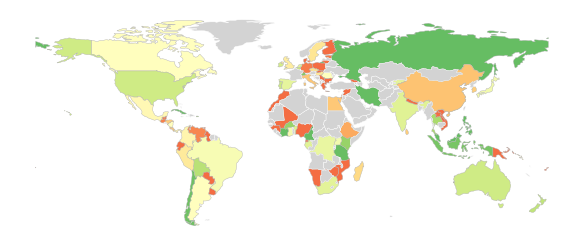

In [121]:
bhm_alpha_country_acc_std_cv.filter(
    (pl.col("Nb_of_sites") >= 25) & (pl.col("Nb_of_studies") >= 2)
)

fig = plot_world_heatmap(
    bhm_alpha_country_acc_std_cv,
    value_col="Average_r",
    min_max=(vmin, vmax),
    figsize=(6, 4.5),
    cmap=cmap,
    show_legend=False,
    legend_label="Average Pearson r",
    legend_decimals=True,
)

In [122]:
fig.savefig(
    "../../documents/plots/world_heatmap_alpha_site.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

## Fig 5b) BHM beta model accuracy, standard CV

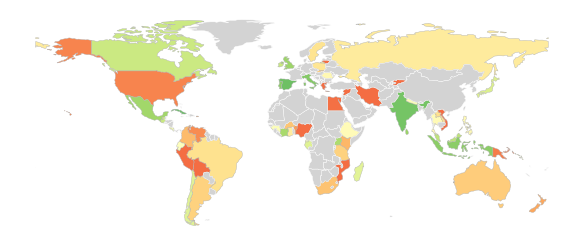

In [123]:
bhm_beta_country_acc_std_cv.filter(
    (pl.col("Nb_of_sites") >= 25) & (pl.col("Nb_of_studies") >= 2)
)

# Plot the expected accuracy per country
fig = plot_world_heatmap(
    bhm_beta_country_acc_std_cv,
    value_col="Average_r",
    min_max=(vmin, vmax),
    figsize=(6, 4.5),
    cmap=cmap,
    show_legend=False,
    legend_label="Average Pearson r",
    legend_decimals=True,
)

In [124]:
fig.savefig(
    "../../documents/plots/world_heatmap_beta_site.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)

## Accuracy heatmap legend

0.0 0.6783163971219945


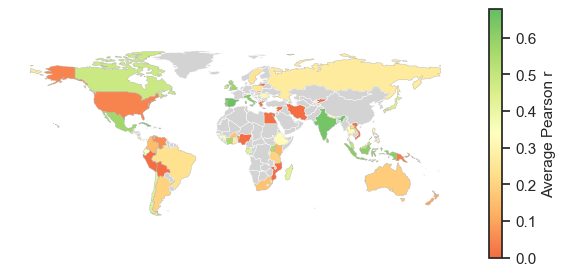

In [125]:
bhm_beta_country_acc_std_cv.filter(
    (pl.col("Nb_of_sites") >= 50) & (pl.col("Nb_of_studies") >= 3)
)

print(vmin, vmax)

# Plot the expected accuracy per country
fig = plot_world_heatmap(
    bhm_beta_country_acc_std_cv,
    value_col="Average_r",
    min_max=(vmin, vmax),
    figsize=(6, 4.5),
    cmap=cmap,
    show_legend=True,
    legend_label="Average Pearson r",
    legend_decimals=True,
)
fig.savefig(
    "../../documents/plots/world_heatmap_bhm_legend.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
)